In [24]:
# Import essential libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import scipy.stats  # Ensure compatibility with future updates

# Set Seaborn style
sb.set()

In [25]:
# Load the dataset
data = pd.read_csv('combined_cleaned_cardio_data.csv')

In [26]:

# Feature selection
features = ["age", "height", "weight", "ap_hi", "ap_lo", "bmi", "cholesterol", "gluc", "smoke", "alco", "active"]
X = data[features]  # Independent variables
y = data["cardio"]  # Dependent variable (target)

In [27]:
# Handle missing values for numeric columns
X = X.apply(lambda col: col.fillna(col.mean()) if col.dtype in ['float64', 'int64'] else col)

In [28]:
# Encode categorical variables
categorical_features = ["cholesterol", "gluc", "smoke", "alco", "active"]
for feature in categorical_features:
    X[feature] = pd.factorize(X[feature])[0]

In [29]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Create and fit the kNN model
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)

# Future-proofing: Ensure compatibility with `stats.mode` changes
scipy.stats.mode = lambda a, axis=0, keepdims=True: scipy.stats._stats_py.mode(a, axis=axis, keepdims=keepdims)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [31]:
# Predict on the test set
y_pred = knn.predict(X_test)

In [32]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")


Confusion Matrix:
[[4908 2080]
 [2339 4673]]

Classification Report:
              precision    recall  f1-score   support

       False       0.68      0.70      0.69      6988
        True       0.69      0.67      0.68      7012

    accuracy                           0.68     14000
   macro avg       0.68      0.68      0.68     14000
weighted avg       0.68      0.68      0.68     14000


Accuracy: 0.68


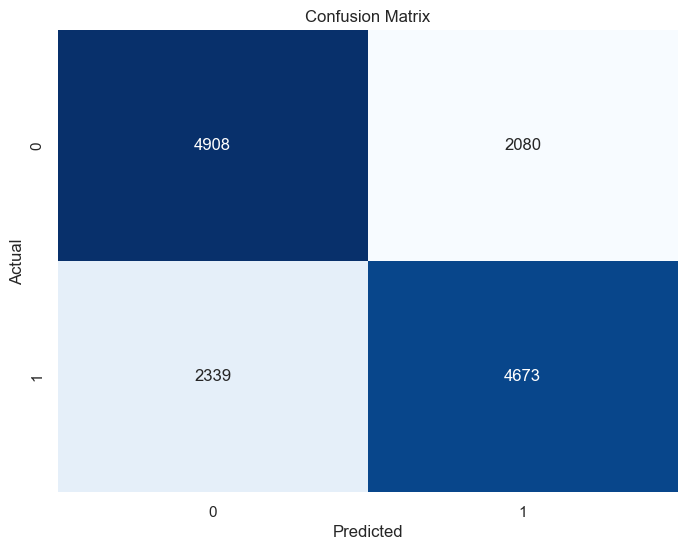

In [33]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sb.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()